# LIKWID policy-* summary

Run this notebook from a policy folder such as `performance/` or `ondemand/`.
It auto-detects subfolders like `<policy>-*` and computes:
- Total runtime [s]
- Average total power [W]
- Total energy [J]
- EDP [J*s]

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Settings
base_dir = Path('.')  # run from policy folder (e.g., performance/, ondemand/)
policy_name = base_dir.resolve().name
subfolder_pattern = f'{policy_name}-*'
benchmark_name = None  # None => process all detected benchmarks; set to a name to filter
skip_initial = 3
output_dir = base_dir  # per-benchmark CSV files are written here


In [2]:
import sys
from pathlib import Path

repo_root = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / 'tests' / 'common' / 'process_profiles_lib.py').is_file():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError('Could not locate tests/common/process_profiles_lib.py from current notebook path')

lib_dir = repo_root / 'tests' / 'common'
if str(lib_dir) not in sys.path:
    sys.path.insert(0, str(lib_dir))

from process_profiles_lib import (
    SUM_FIELDS,
    build_policy_summary,
    extract_job_id,
    find_stdout_for_job,
    list_profiles,
    load_likwid_profile,
    newest_profile_for_benchmark,
    plot_benchmark_boxplots,
    plot_likwid_timeseries,
    print_policy_context,
    run_has_fatal_error,
    summarize_profile,
)


In [3]:
per_benchmark_summary, all_output = build_policy_summary(
    base_dir=base_dir,
    subfolder_pattern=subfolder_pattern,
    benchmark_name=benchmark_name,
    skip_initial=skip_initial,
    output_dir=output_dir,
    policy_name=policy_name,
)

print_policy_context(policy_name, subfolder_pattern, benchmark_name)
all_output


Removed 31 extreme-high LIKWID samples using automatic power filtering
Removed 8 extreme-high LIKWID samples using automatic power filtering
Removed 4 extreme-high LIKWID samples using automatic power filtering
Skipping ondemand-0/fotonik3d: found fatal error markers in speccpu_fotonik3d.37347.prof
Removed 20 extreme-high LIKWID samples using automatic power filtering
Removed 12 extreme-high LIKWID samples using automatic power filtering
Removed 33 extreme-high LIKWID samples using automatic power filtering
Removed 6 extreme-high LIKWID samples using automatic power filtering
Skipping ondemand-0/perlbench: found fatal error markers in speccpu_perlbench.37353.out
Removed 37 extreme-high LIKWID samples using automatic power filtering
Removed 32 extreme-high LIKWID samples using automatic power filtering
Skipping ondemand-0/x264: found fatal error markers in speccpu_x264.37356.prof
Skipping ondemand-0/xalancbmk: found fatal error markers in speccpu_xalancbmk.37357.out
Removed 120 extreme-

,subfolder,benchmark,Total runtime [s],Average total power [W],Total energy [J],EDP [J*s]
0,Average,cam4,3855.75,525.81,2026828.78,7.815027e+09
1,ondemand-0,cam4,3864.03,525.54,2030111.60,7.844406e+09
2,ondemand-1,cam4,3860.54,532.84,2056616.13,7.939653e+09
3,ondemand-2,cam4,3843.88,530.59,2038877.33,7.837193e+09
4,ondemand-3,cam4,3847.16,515.61,1983028.44,7.629020e+09
...,...,...,...,...,...,...
61,ondemand-0,xz,2191.77,472.30,1035540.85,2.269669e+09
62,ondemand-1,xz,2177.31,475.11,1036135.18,2.255986e+09
63,ondemand-2,xz,2185.69,475.77,1041415.26,2.276212e+09
64,ondemand-3,xz,2187.71,473.13,1036906.00,2.268454e+09


Removed 30 extreme-high samples from 'Power L3 [W]' using upper bound 771


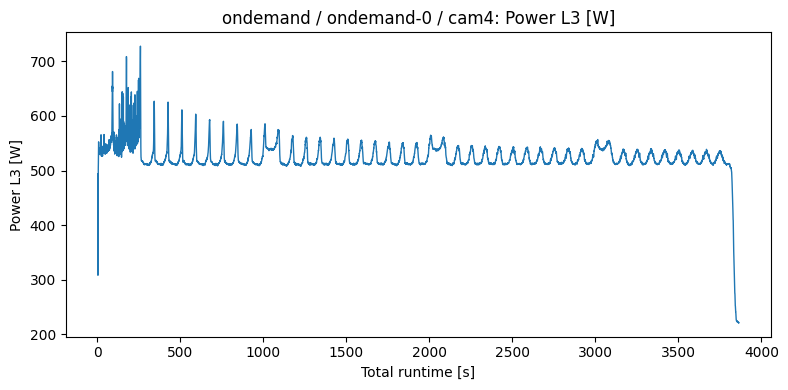

In [4]:
# Plot LIKWID sample time-series for one subfolder/benchmark and one field
selected_subfolder = 'ondemand-0'
selected_benchmark = None  # None => auto-pick first benchmark found in selected_subfolder
selected_field = 'Power L3 [W]'

plot_likwid_timeseries(
    base_dir=base_dir,
    selected_subfolder=selected_subfolder,
    selected_benchmark=selected_benchmark,
    selected_field=selected_field,
    skip_initial=skip_initial,
    policy_name=policy_name,
    include_benchmark_in_title=True,
)


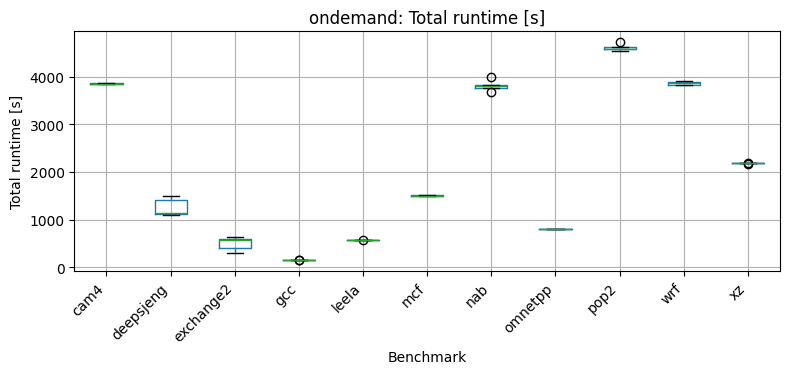

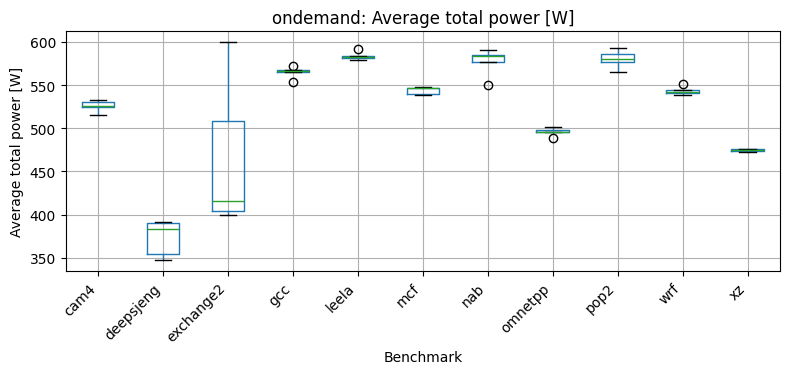

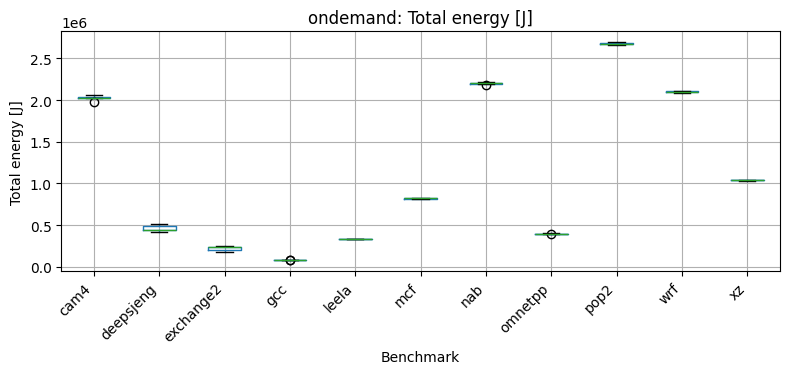

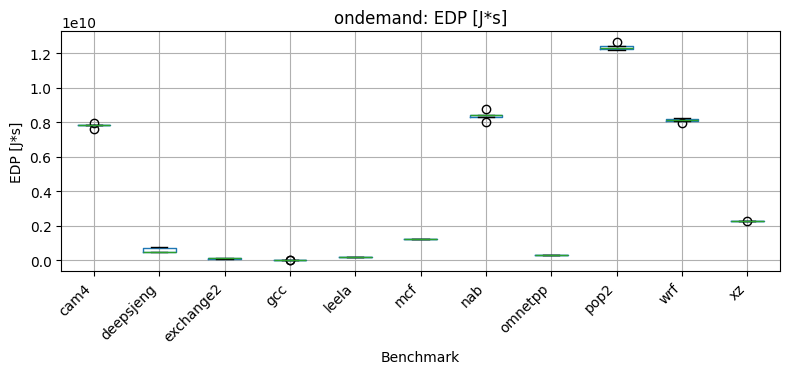

In [5]:
plot_metrics = [
    'Total runtime [s]',
    'Average total power [W]',
    'Total energy [J]',
    'EDP [J*s]',
]

plot_benchmark_boxplots(
    per_benchmark_summary=per_benchmark_summary,
    policy_name=policy_name,
    plot_metrics=plot_metrics,
)
